# 03 Adversarial Advantage Data

Analyzes observed synthetic QKD leakage and PQC adversarial-advantage proxies and their DDS product bound.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
g=df.groupby("scenario").agg(QKD_leakage=("qkd_information_leakage","mean"),
PQC_advantage=("pqc_adversarial_advantage","mean"))
g["DDS_product_bound"]=g.QKD_leakage*g.PQC_advantage
g["gain_vs_best_single"]=np.minimum(g.QKD_leakage,g.PQC_advantage)/g.DDS_product_bound
g.to_csv(OUT/"adversarial_advantage_by_scenario.csv"); display(g)

,QKD_leakage,PQC_advantage,DDS_product_bound,gain_vs_best_single
scenario,,,,
S1_Normal,0.035376,0.182705,0.006463,5.473315
S2_Quantum_Eavesdropping,0.199875,0.316893,0.063339,3.155644
S3_Harvest_Now_Decrypt_Later,0.053617,0.286448,0.015359,3.491031
S4_QKD_Link_Failure,0.344744,0.312017,0.107566,2.900700
S5_PQC_Computational_Overload,0.071359,0.406588,0.029014,2.459493
S6_Hybrid_Adversarial_Attack,0.188551,0.410131,0.077330,2.438248


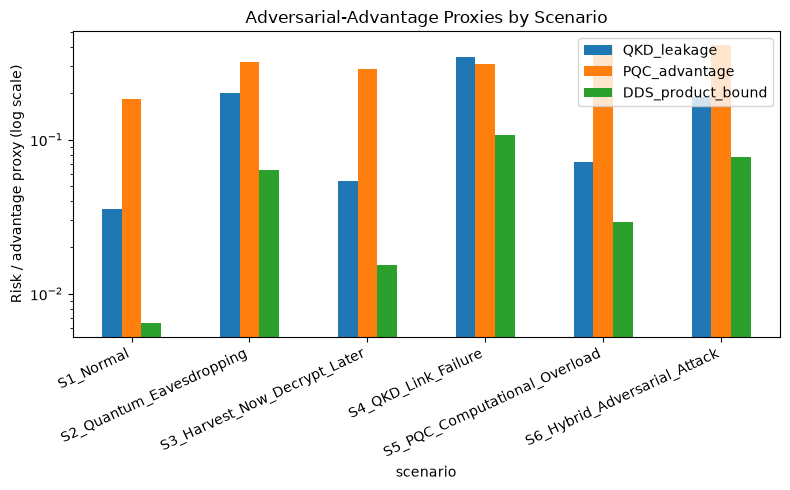

In [3]:
plt.figure(figsize=(8,5)); g[["QKD_leakage","PQC_advantage","DDS_product_bound"]].plot(kind="bar",ax=plt.gca(),logy=True)
plt.ylabel("Risk / advantage proxy (log scale)"); plt.title("Adversarial-Advantage Proxies by Scenario")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.savefig(OUT/"fig_adversarial_advantage_data.png",dpi=300); plt.show()